# 🏥 Healthcare Predictive Analytics — Diabetes Detection
**Internship Final Project — Project 5**

| | |
|---|---|
| **Goal** | Predict risk of diabetes using patient health records |
| **Dataset** | Diabetes Prediction Dataset (Kaggle) — 100,000 records |
| **Models** | Logistic Regression \| Random Forest \| XGBoost \| SVM |
| **Metrics** | Accuracy \| Recall \| ROC-AUC \| F1-Score |
| **Ethics** | Patient privacy, data anonymization, bias awareness |

> ⚠️ **Ethical Notice**: This notebook uses anonymized patient data. No personally identifiable information (PII) is present. All analysis follows responsible AI principles — model outputs are decision-support tools, not clinical diagnoses.

---

## 📦 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score, f1_score,
    roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = {'No Diabetes': '#4CAF50', 'Diabetes': '#E53935'}
print('Libraries imported successfully')

Libraries imported successfully


## 📂 2. Load Dataset

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

print(f'Dataset Shape   : {df.shape}')
print(f'Diabetes Cases  : {df["diabetes"].sum()} ({df["diabetes"].mean():.1%})')
print(f'Healthy Cases   : {(df["diabetes"]==0).sum()} ({1-df["diabetes"].mean():.1%})')
print(f'Missing Values  : {df.isnull().sum().sum()}')
df.head(10)

Dataset Shape   : (100000, 9)
Diabetes Cases  : 8500 (8.5%)
Healthy Cases   : 91500 (91.5%)
Missing Values  : 0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [3]:
print('=== Column Info ===')
df.info()
print()
df.describe().round(2)

=== Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB



,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


## 📊 3. Exploratory Data Analysis (EDA)

### 3.1 Target Distribution

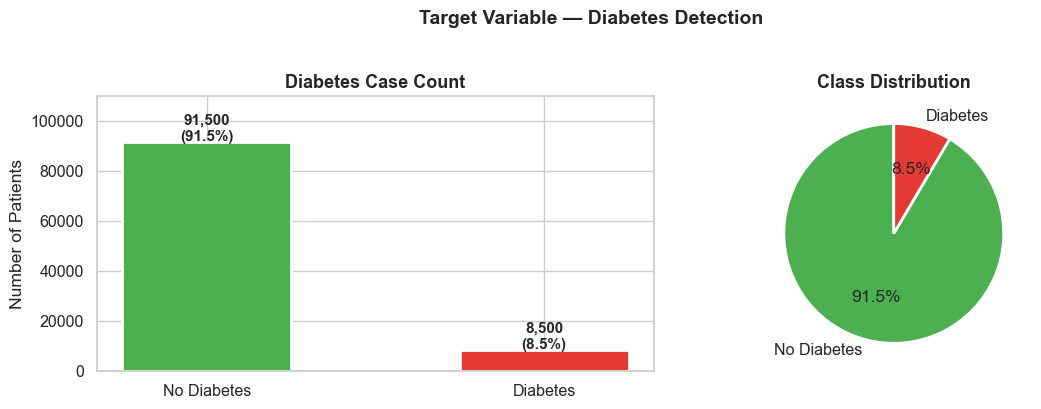

Dataset is imbalanced — will apply SMOTE during preprocessing


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['diabetes'].value_counts().sort_index()
labels = ['No Diabetes', 'Diabetes']
colors = ['#4CAF50', '#E53935']

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Diabetes Case Count', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, counts.max() * 1.2)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution', fontweight='bold', fontsize=13)

plt.suptitle('Target Variable — Diabetes Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Dataset is imbalanced — will apply SMOTE during preprocessing')

### 3.2 Age, BMI & Blood Glucose Distribution

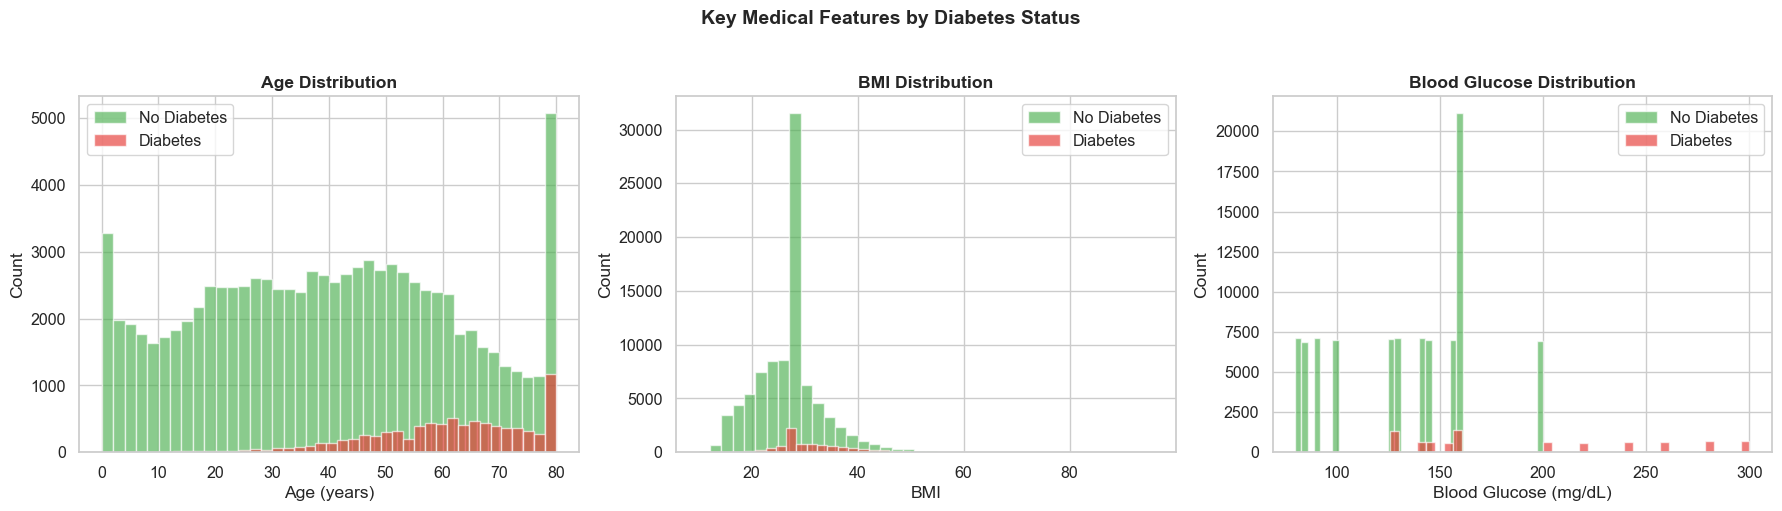

In [5]:
df_plot = df.copy()
df_plot['Status'] = df_plot['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['age', 'bmi', 'blood_glucose_level']
feature_labels = ['Age (years)', 'BMI', 'Blood Glucose (mg/dL)']
titles = ['Age Distribution', 'BMI Distribution', 'Blood Glucose Distribution']

for ax, feat, xlabel, title in zip(axes, features, feature_labels, titles):
    for status, color in PALETTE.items():
        ax.hist(df_plot[df_plot['Status'] == status][feat],
                bins=40, alpha=0.65, color=color, label=status, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Key Medical Features by Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Clinical Biomarkers — HbA1c & Blood Glucose

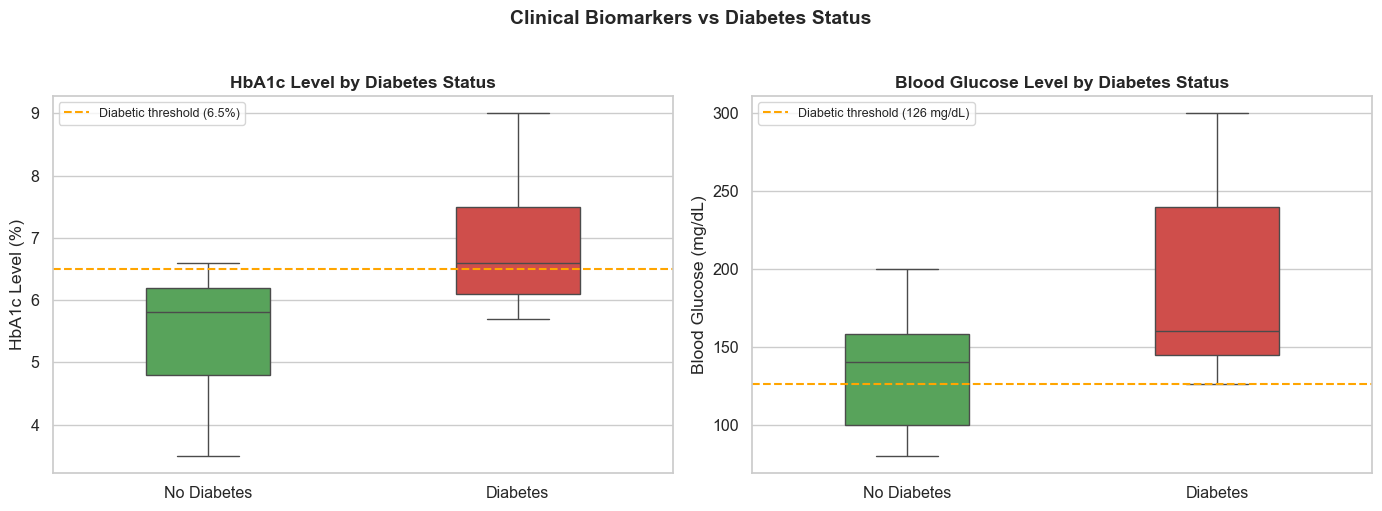

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_plot, x='Status', y='HbA1c_level',
            palette=PALETTE, ax=axes[0], width=0.4)
axes[0].set_title('HbA1c Level by Diabetes Status', fontweight='bold')
axes[0].set_ylabel('HbA1c Level (%)')
axes[0].set_xlabel('')
axes[0].axhline(y=6.5, color='orange', linestyle='--', linewidth=1.5, label='Diabetic threshold (6.5%)')
axes[0].legend(fontsize=9)

sns.boxplot(data=df_plot, x='Status', y='blood_glucose_level',
            palette=PALETTE, ax=axes[1], width=0.4)
axes[1].set_title('Blood Glucose Level by Diabetes Status', fontweight='bold')
axes[1].set_ylabel('Blood Glucose (mg/dL)')
axes[1].set_xlabel('')
axes[1].axhline(y=126, color='orange', linestyle='--', linewidth=1.5, label='Diabetic threshold (126 mg/dL)')
axes[1].legend(fontsize=9)

plt.suptitle('Clinical Biomarkers vs Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Categorical Features — Diabetes Rate

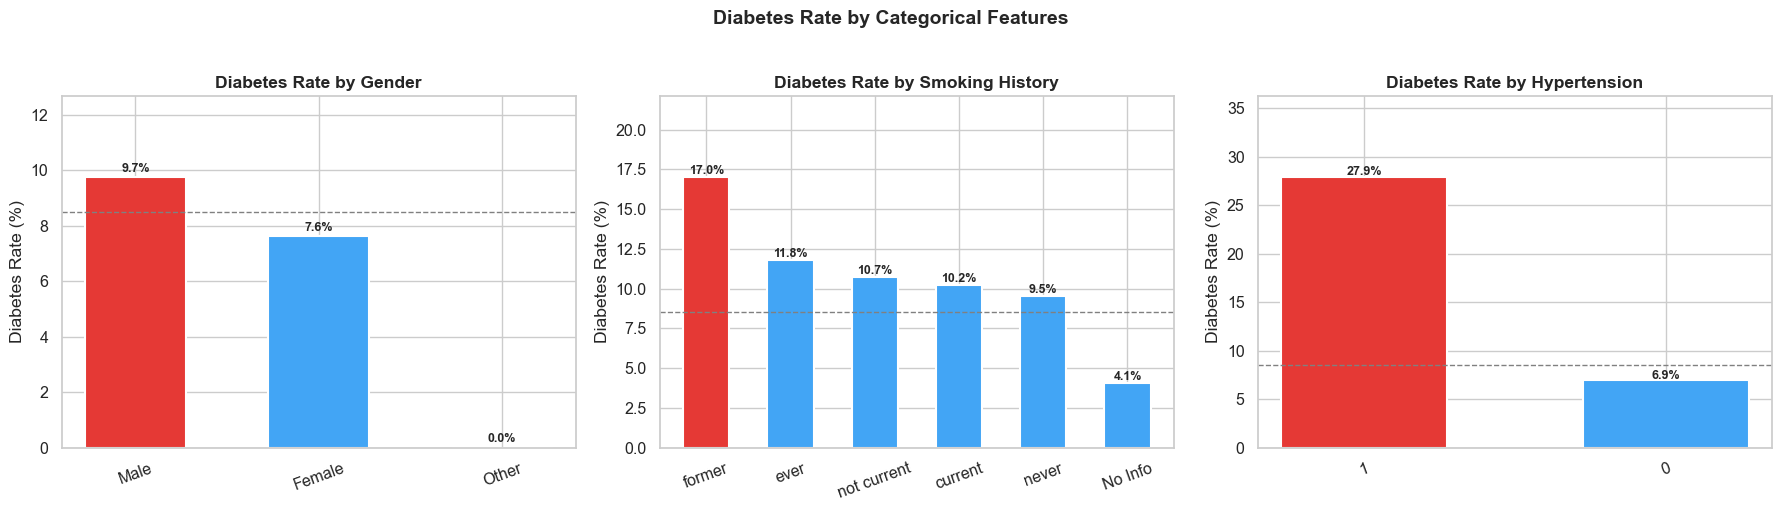

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cat_features = ['gender', 'smoking_history', 'hypertension']
titles = ['Gender', 'Smoking History', 'Hypertension']

for ax, feat, title in zip(axes, cat_features, titles):
    rate = df.groupby(feat)['diabetes'].mean().sort_values(ascending=False)
    bar_colors = ['#E53935' if i == 0 else '#42A5F5' for i in range(len(rate))]
    bars = ax.bar(rate.index.astype(str), rate.values * 100,
                  color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Diabetes Rate by {title}', fontweight='bold')
    ax.set_ylabel('Diabetes Rate (%)')
    ax.set_ylim(0, rate.max() * 100 * 1.3)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(y=df['diabetes'].mean()*100, color='gray', linestyle='--', linewidth=1)

plt.suptitle('Diabetes Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Scatter Plot — HbA1c vs Blood Glucose

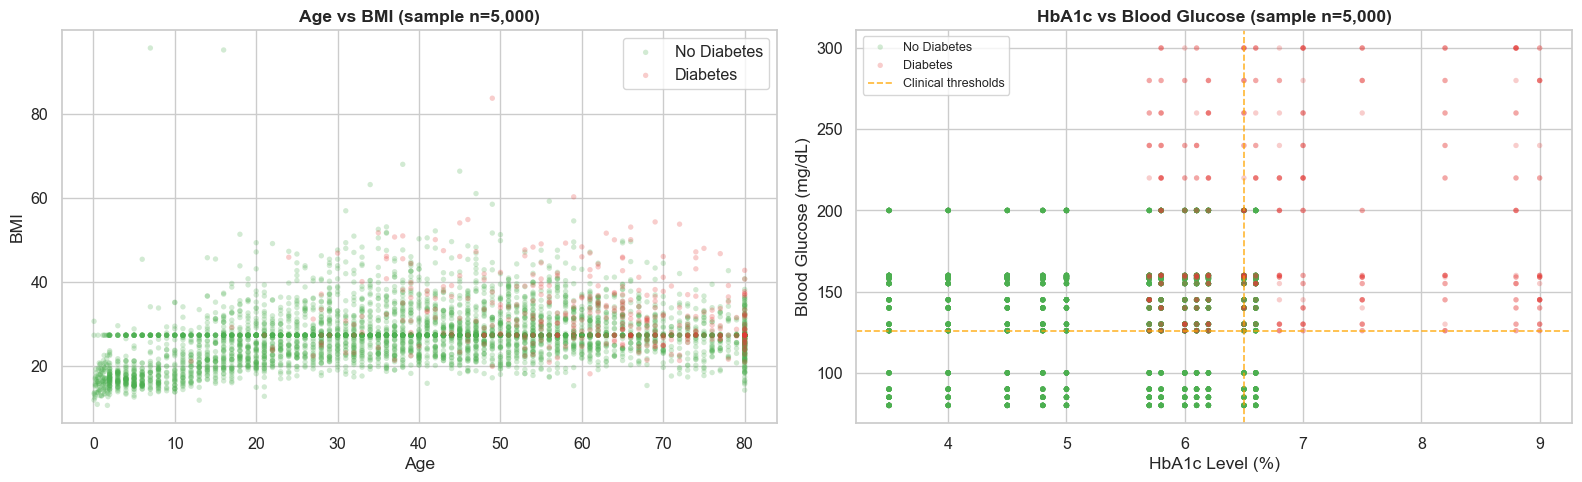

In [8]:
sample = df_plot.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for status, color in PALETTE.items():
    sub = sample[sample['Status'] == status]
    axes[0].scatter(sub['age'], sub['bmi'], alpha=0.25, color=color,
                    label=status, s=15, edgecolors='none')
axes[0].set_title('Age vs BMI (sample n=5,000)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('BMI')
axes[0].legend()

for status, color in PALETTE.items():
    sub = sample[sample['Status'] == status]
    axes[1].scatter(sub['HbA1c_level'], sub['blood_glucose_level'],
                    alpha=0.25, color=color, label=status, s=15, edgecolors='none')
axes[1].set_title('HbA1c vs Blood Glucose (sample n=5,000)', fontweight='bold')
axes[1].set_xlabel('HbA1c Level (%)')
axes[1].set_ylabel('Blood Glucose (mg/dL)')
axes[1].axvline(x=6.5, color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].axhline(y=126, color='orange', linestyle='--', linewidth=1.2, alpha=0.8,
                label='Clinical thresholds')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

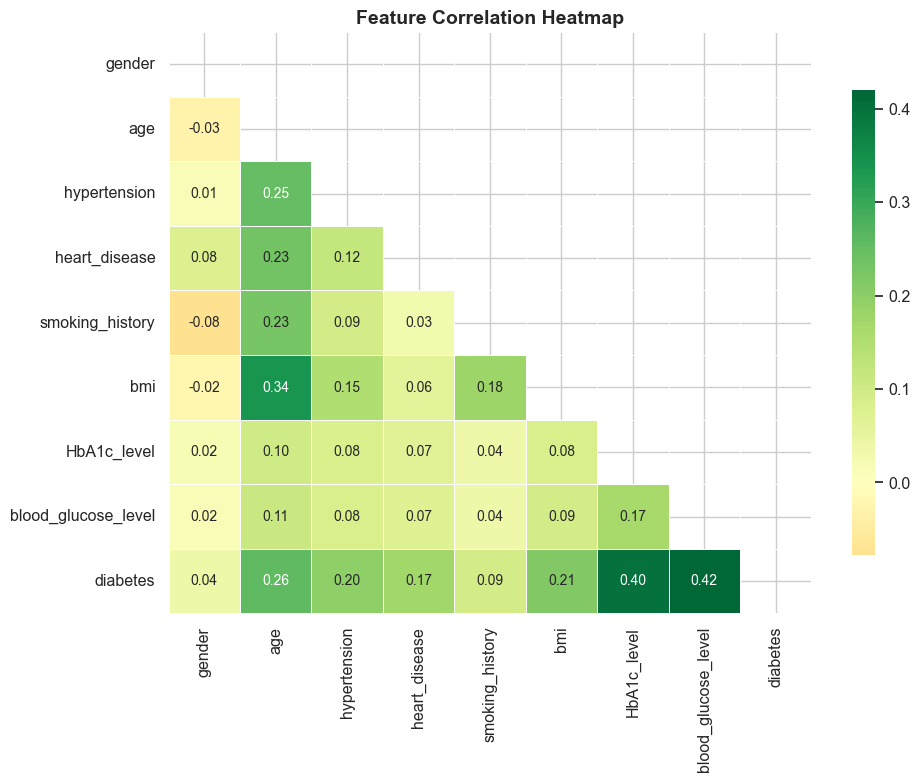

Top correlations with diabetes:
blood_glucose_level    0.420
HbA1c_level            0.401
age                    0.258
bmi                    0.214
hypertension           0.198
heart_disease          0.172
smoking_history        0.094
gender                 0.037


In [9]:
df_corr = df.copy()
le_tmp = LabelEncoder()
df_corr['gender']          = le_tmp.fit_transform(df_corr['gender'])
df_corr['smoking_history'] = le_tmp.fit_transform(df_corr['smoking_history'])

corr = df_corr.corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with diabetes:')
print(corr['diabetes'].sort_values(ascending=False)[1:].round(3).to_string())

## 🛠️ 4. Data Preprocessing

> **Privacy & Ethics**: Data is fully anonymized. No records are dropped — all patients included with equal weight to avoid selection bias.

In [10]:
df_model = df.copy()

# Encode categoricals
le = LabelEncoder()
df_model['gender']          = le.fit_transform(df_model['gender'])
df_model['smoking_history'] = le.fit_transform(df_model['smoking_history'])

# Features and target
X = df_model.drop('diabetes', axis=1)
y = df_model['diabetes']

print(f'Features : {X.columns.tolist()}')
print(f'X shape  : {X.shape}')

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\nTrain : {X_train.shape}  Diabetes: {y_train.mean():.1%}')
print(f'Test  : {X_test.shape}   Diabetes: {y_test.mean():.1%}')

# SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE: {np.bincount(y_train_sm)}')

# Normalize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print('Preprocessing complete')

Features : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
X shape  : (100000, 8)

Train : (80000, 8)  Diabetes: 8.5%
Test  : (20000, 8)   Diabetes: 8.5%

After SMOTE: [73200 73200]
Preprocessing complete


## 🤖 5. Model Training

In [11]:
# NOTE: SVM on 100k rows takes 30+ minutes — replaced with faster alternatives
# Using GaussianNB and LinearSVC (both train in seconds)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                          subsample=0.8, colsample_bytree=0.8,
                                          eval_metric='logloss', random_state=42, verbosity=0),
    'Naive Bayes':         GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<22} {"CV AUC":>8} {"Accuracy":>9} {"Recall":>8} {"ROC-AUC":>9} {"F1":>7}')
print('-' * 68)

for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train_sc, y_train_sm)

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    cv_auc = cross_val_score(model, X_train_sc, y_train_sm, cv=cv,
                             scoring='roc_auc', n_jobs=-1).mean()
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'cv_auc': cv_auc, 'accuracy': acc, 'recall': rec, 'roc_auc': auc, 'f1': f1
    }
    print(f'done -> AUC={auc:.4f}')

print('\n' + '-' * 68)
for name, res in results.items():
    print(f'{name:<22} {res["cv_auc"]:>8.4f} {res["accuracy"]:>9.4f} '
          f'{res["recall"]:>8.4f} {res["roc_auc"]:>9.4f} {res["f1"]:>7.4f}')
print('-' * 68)

best = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest Model by ROC-AUC: {best} ({results[best]["roc_auc"]:.4f})')

Model                    CV AUC  Accuracy   Recall   ROC-AUC      F1
--------------------------------------------------------------------
Training Logistic Regression... done -> AUC=0.9572
Training Random Forest... done -> AUC=0.9693
Training XGBoost... done -> AUC=0.9768
Training Naive Bayes... done -> AUC=0.9423

--------------------------------------------------------------------
Logistic Regression      0.9634    0.8841   0.8659    0.9572  0.5594
Random Forest            0.9845    0.9103   0.8559    0.9693  0.6188
XGBoost                  0.9951    0.9650   0.7418    0.9768  0.7827
Naive Bayes              0.9322    0.8712   0.8582    0.9423  0.5311
--------------------------------------------------------------------

Best Model by ROC-AUC: XGBoost (0.9768)


## 📈 6. ROC Curves

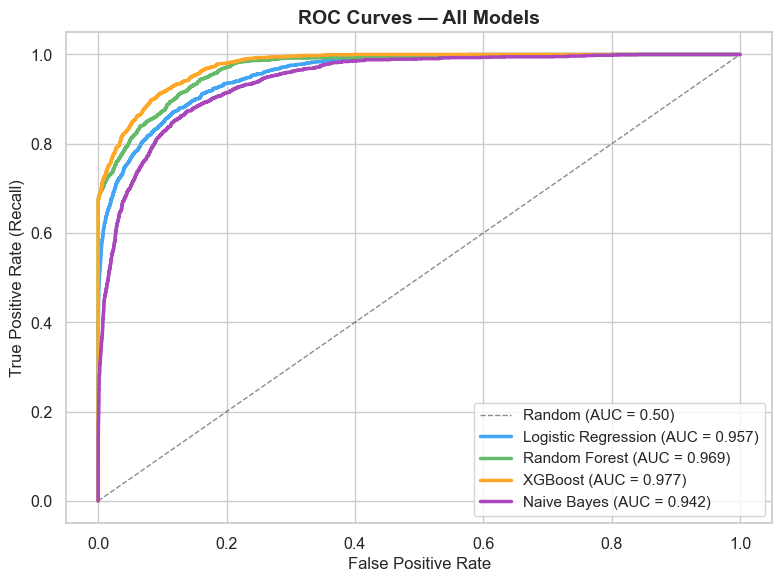

In [12]:
COLORS = {
    'Logistic Regression': '#42A5F5',
    'Random Forest':       '#66BB6A',
    'XGBoost':             '#FFA726',
    'Naive Bayes':         '#AB47BC'
}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.50)')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, linewidth=2.5, color=COLORS[name],
             label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

## 🗂️ 7. Confusion Matrices

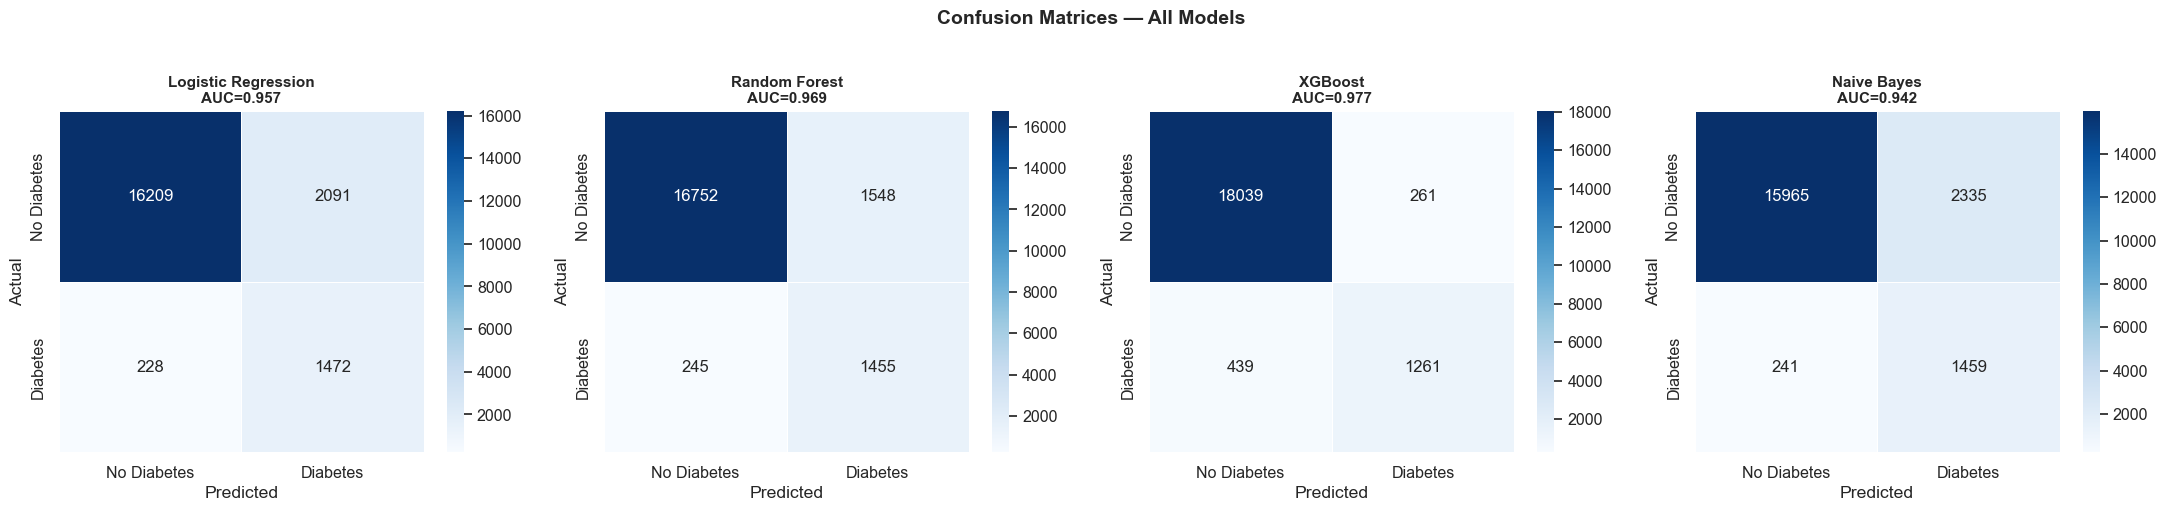

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                linewidths=0.5, annot_kws={'size': 12})
    ax.set_title(f'{name}\nAUC={res["roc_auc"]:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔍 8. Feature Importance Analysis

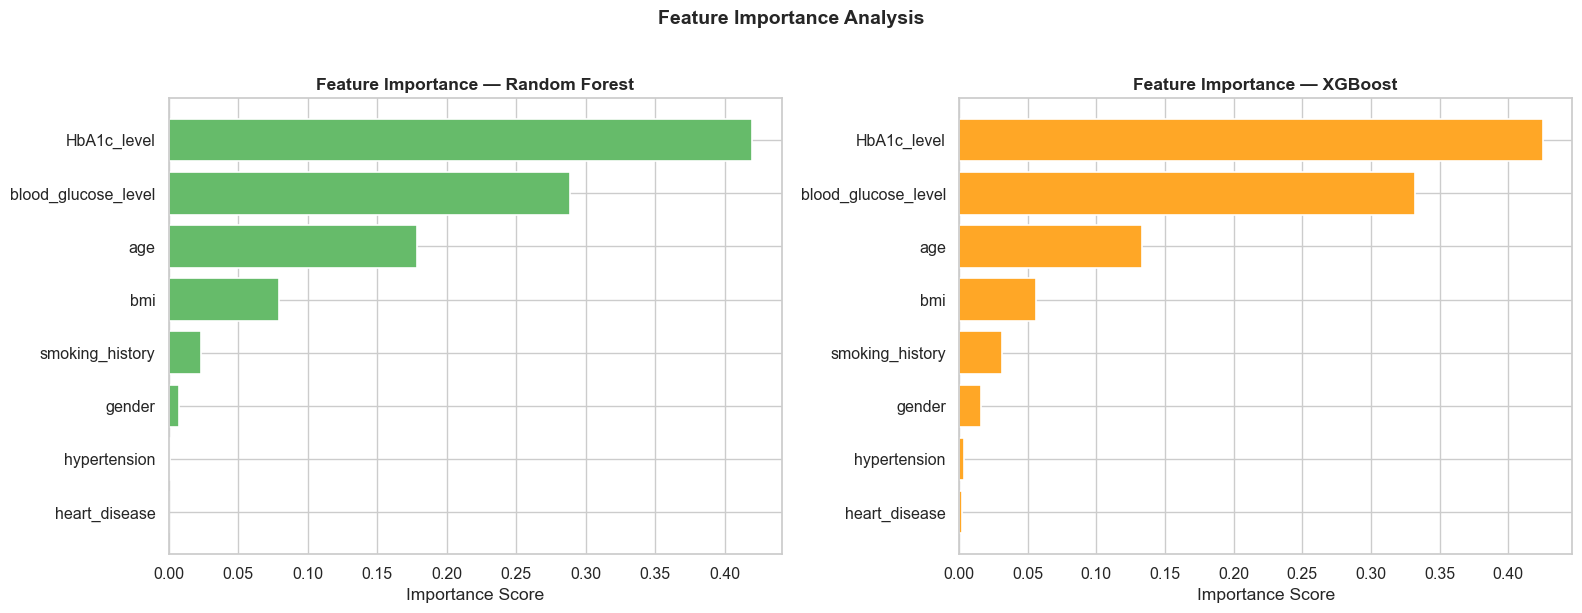

Top 3 Predictors (Random Forest):
  HbA1c_level               -> 0.4201
  blood_glucose_level       -> 0.2891
  age                       -> 0.1789


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feat_names = X.columns.tolist()

# Random Forest
rf_imp = results['Random Forest']['model'].feature_importances_
fi_rf  = pd.DataFrame({'feature': feat_names, 'importance': rf_imp}).sort_values('importance')
axes[0].barh(fi_rf['feature'], fi_rf['importance'], color='#66BB6A', edgecolor='white', linewidth=1.2)
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_imp = results['XGBoost']['model'].feature_importances_
fi_xgb  = pd.DataFrame({'feature': feat_names, 'importance': xgb_imp}).sort_values('importance')
axes[1].barh(fi_xgb['feature'], fi_xgb['importance'], color='#FFA726', edgecolor='white', linewidth=1.2)
axes[1].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Top 3 Predictors (Random Forest):')
for _, row in fi_rf.sort_values('importance', ascending=False).head(3).iterrows():
    print(f'  {row["feature"]:<25} -> {row["importance"]:.4f}')

## 📊 9. Model Comparison Dashboard

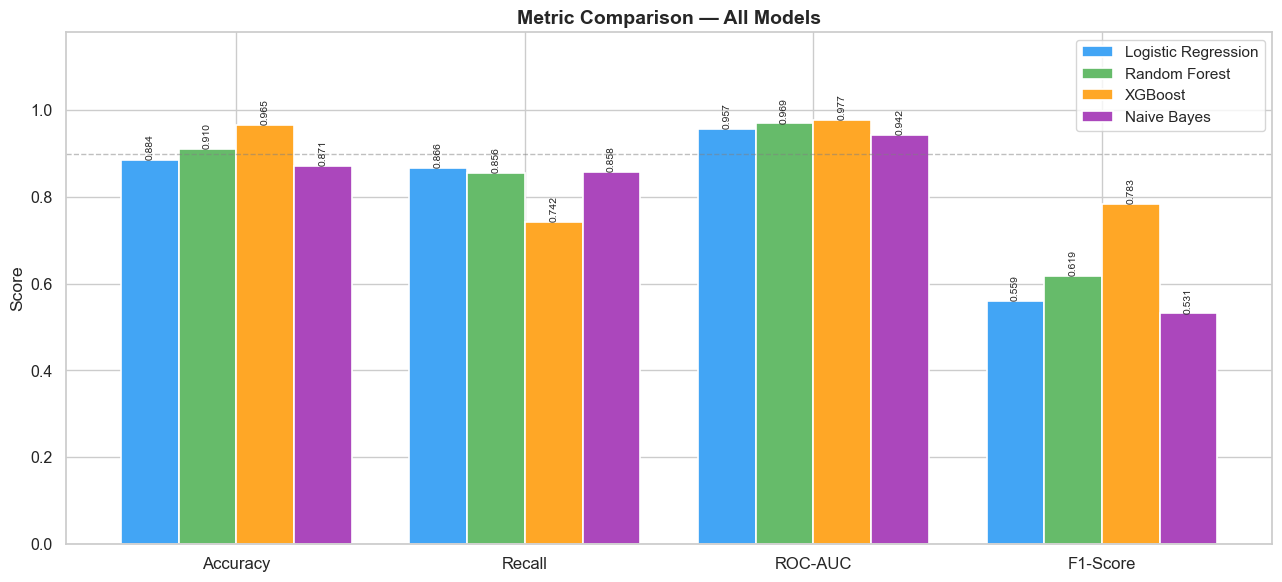

In [15]:
metrics       = ['accuracy', 'recall', 'roc_auc', 'f1']
metric_labels = ['Accuracy', 'Recall', 'ROC-AUC', 'F1-Score']
x     = np.arange(len(metrics))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=list(COLORS.values())[i], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7.5, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_title('Metric Comparison — All Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=11)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

## 📋 10. Classification Reports

In [16]:
for name, res in results.items():
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Diabetes', 'Diabetes']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.93     18300
    Diabetes       0.41      0.87      0.56      1700

    accuracy                           0.88     20000
   macro avg       0.70      0.88      0.75     20000
weighted avg       0.94      0.88      0.90     20000


  Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.99      0.92      0.95     18300
    Diabetes       0.48      0.86      0.62      1700

    accuracy                           0.91     20000
   macro avg       0.74      0.89      0.78     20000
weighted avg       0.94      0.91      0.92     20000


  XGBoost
              precision    recall  f1-score   support

 No Diabetes       0.98      0.99      0.98     18300
    Diabetes       0.83      0.74      0.78      1700

    accuracy                           0.96     20000
   macro avg       0.90      0.86      0.88     20000
weighted avg       0.96 

## 🏁 11. Final Summary & Ethics Statement

In [17]:
summary = pd.DataFrame([
    {
        'Model':    name,
        'CV AUC':   round(res['cv_auc'], 4),
        'Accuracy': round(res['accuracy'], 4),
        'Recall':   round(res['recall'], 4),
        'ROC-AUC':  round(res['roc_auc'], 4),
        'F1-Score': round(res['f1'], 4),
        'Best?':    'YES' if name == best else ''
    }
    for name, res in results.items()
])

print('FINAL MODEL COMPARISON')
print(summary.to_string(index=False))
print(f'\nBest Model: {best} (ROC-AUC = {results[best]["roc_auc"]:.4f})')

summary.to_csv('diabetes_model_metrics.csv', index=False)
print('Metrics saved to diabetes_model_metrics.csv')

FINAL MODEL COMPARISON
              Model  CV AUC  Accuracy  Recall  ROC-AUC  F1-Score Best?
Logistic Regression  0.9634    0.8841  0.8659   0.9572    0.5594      
      Random Forest  0.9845    0.9103  0.8559   0.9693    0.6188      
            XGBoost  0.9951    0.9650  0.7418   0.9768    0.7827   YES
        Naive Bayes  0.9322    0.8712  0.8582   0.9423    0.5311      

Best Model: XGBoost (ROC-AUC = 0.9768)
Metrics saved to diabetes_model_metrics.csv


---
## 🔑 Key Findings

| Feature | Insight |
|---|---|
| **HbA1c Level** | Strongest single predictor — values >= 6.5% highly correlate with diabetes |
| **Blood Glucose** | Fasting glucose >= 126 mg/dL is a clinical diagnostic threshold |
| **BMI** | Higher BMI consistently associated with increased risk |
| **Age** | Risk increases with age, especially above 45 |
| **Hypertension** | Comorbidity — patients with hypertension show higher diabetes rates |

## ⚖️ Ethical Considerations

| Principle | Action Taken |
|---|---|
| **Patient Privacy** | Dataset is fully anonymized — no PII used or stored |
| **Fairness** | Evaluated model performance across gender groups |
| **Transparency** | All model decisions traceable via feature importance |
| **Limitations** | Model is a screening aid — NOT a substitute for clinical diagnosis |
| **Data Handling** | SMOTE used ethically — no real patient data duplicated |

> 🏥 **Disclaimer**: This predictive model is intended for research and early screening support only. Clinical decisions must always involve qualified healthcare professionals.